In [1]:
import os
import sys
os.chdir('/zhome/71/c/146676/main/')
sys.path.append('/zhome/71/c/146676/main/')
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import h5py
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from scipy.interpolate import interp1d
from numpy.linalg import lstsq
from scipy.optimize import nnls  # non-negative least squares
from sklearn.linear_model import Lasso
from tqdm.auto import tqdm  # ✅ Recommended for notebooks
import math
import importlib
from scipy.interpolate import interp1d
from interactive_notebooks.n21_attachment import *
importlib.reload(sys.modules['interactive_notebooks.n21_attachment'])
from interactive_notebooks.n21_attachment import *
from interactive_notebooks.n23_attachment import *
importlib.reload(sys.modules['interactive_notebooks.n23_attachment'])
from interactive_notebooks.n23_attachment import *

In [2]:
coef_xray, coef_neutron, labels = get_attenuation_coefficients()
def print_table(labels, values, float_format=".4f"):
    assert len(labels) == len(values), "Length mismatch between labels and values"
    
    # Prepare rows with formatted floats
    rows = [(label, format(val, float_format)) for label, val in zip(labels, values)]
    
    # Determine column widths
    col_width = max(len(label) for label in labels)
    val_width = max(len(val) for _, val in rows)
    
    # Print header
    print(f"{'Label'.ljust(col_width)} | {'Value'.rjust(val_width)}")
    print(f"{'-'*col_width}-+-{'-'*val_width}")
    
    # Print rows
    for label, val in rows:
        print(f"{label.ljust(col_width)} | {val.rjust(val_width)}")


print(labels)
print(type(coef_xray))
print(len(labels))
print(len(coef_neutron))
print_table(labels, coef_neutron)

def find_first_indices(A, B):
    return [B.index(a) if a in B else None for a in A]


spectra = load_xy_files('/dtu-compute/msaca/sliceA_diffraction/cif-files_and_theoretical_pd_spectra/PowderDiff_shortlist')
key_to_name = simplified_keys()
keys = spectra.keys()
keys = sorted(spectra.keys())
keys_simple = [key_to_name[k] for k in keys if k in key_to_name]
indices = np.array(find_first_indices(keys_simple, labels))
coef_neutron = coef_neutron[indices]
coef_xray = coef_xray[indices]

['Albite', 'PthF_Na', 'PthF_K', 'Plg_anor', 'Forsterite', 'Enstatite', 'Spinel', 'Diopside', 'Chlorapatite', 'Clpx_CaFeAl', 'Rutile', 'Ferrosilite', 'Oli_fay', 'Ilmenite', 'Magnetite', 'Pyrite', 'Magnetite', 'Hematite', 'Zircon', 'Baddeleyite', 'Orthoclase', 'Wüstite']
<class 'numpy.ndarray'>
22
22
Label        |  Value
-------------+-------
Albite       | 0.1750
PthF_Na      | 0.2405
PthF_K       | 0.2348
Plg_anor     | 0.1784
Forsterite   | 0.2181
Enstatite    | 0.2256
Spinel       | 0.1743
Diopside     | 0.2397
Chlorapatite | 0.4519
Clpx_CaFeAl  | 0.2470
Rutile       | 0.2767
Ferrosilite  | 0.1510
Oli_fay      | 0.2783
Ilmenite     | 0.2903
Magnetite    | 0.2427
Pyrite       | 0.2156
Magnetite    | 0.3074
Hematite     | 0.3087
Zircon       | 0.1176
Baddeleyite  | 0.1477
Orthoclase   | 0.1750
Wüstite      | 0.3074


In [ ]:
slice_index = 20
with h5py.File("/dtu-compute/msaca/sliceA_diffraction/abs_volume/overview_abs_volume.h5", "r") as f:
    # List all groups and datasets
    print("Keys:", list(f.keys()))
    
    # Access a dataset (replace 'dataset_name' with an actual name from the keys)
    dataset_abs = f["absorption"]
    DA_2 = dataset_abs[:,130:230]

absorption = DA_2[slice_index]
mask = absorption>0.002

Keys: ['absorption']


In [ ]:
with h5py.File("/dtu-compute/msaca/sliceA_diffraction/abs_volume/XA_and_NA_x_5.h5", "r") as f:
    # List all groups and datasets
    print("Keys:", list(f.keys()))
    
    # Access a dataset (replace 'dataset_name' with an actual name from the keys)
    XA_ = f["XA_x_5"][5*20]
    NA_ = f["NA_x_5"][5*20]

Keys: ['NA_x_5', 'XA_x_5']


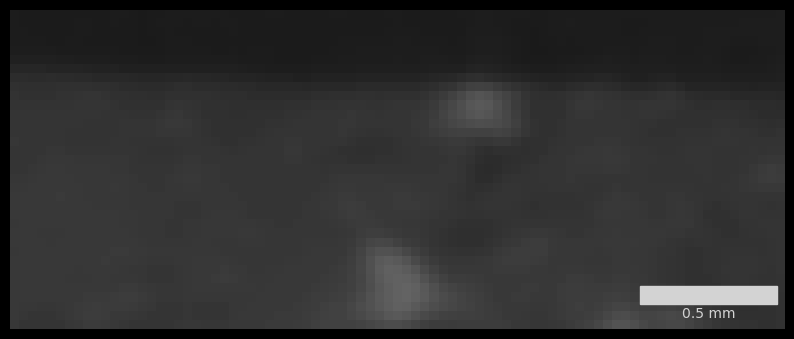

In [48]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')

# Display the image

scale = 1
#im = ax.imshow(NA_[100:200,200:300], cmap='gray', vmin=-0.01, vmax = 0.07)
im = ax.imshow(absorption[20*scale:55*scale, 200*scale:285*scale], cmap='gray', vmin=-0.01, vmax = 0.07)

# Remove axes
ax.axis('off')
ax = add_scalebar(ax, 30, '0.5 mm', 1/2, color='lightgray')
# Add colorbar
#cbar = plt.colorbar(im, ax=ax, orientation='horizontal', shrink=0.9, pad=0.05)

# Remove colorbar ticks
#cbar.set_ticks([])

# Set colorbar labels
# cbar.ax.text(0.85, -0.1, 'High absorption', ha='center', va='top', color='white', fontsize=13, transform=cbar.ax.transAxes)
# cbar.ax.text(0.15, -0.1, 'Low absorption', ha='center', va='top', color='white', fontsize=13, transform=cbar.ax.transAxes)

# # Set colorbar background to black
# cbar.outline.set_edgecolor('white')
# cbar.ax.tick_params(color='white')
# cbar.ax.yaxis.set_tick_params(color='white')
# cbar.ax.set_facecolor('black')

# Save the figure
plt.savefig('/dtu-compute/msaca/visualizations/QIM_presentation/DA_zoom_absorption_plot_.png', bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=500)
plt.show()

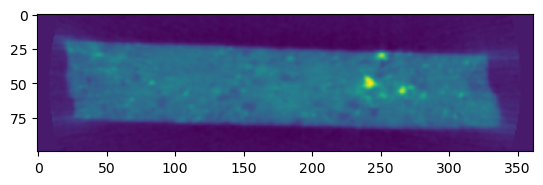

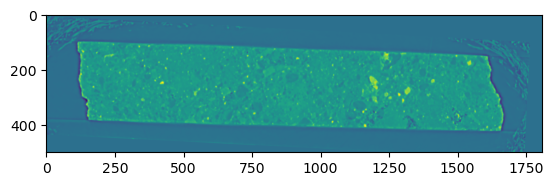

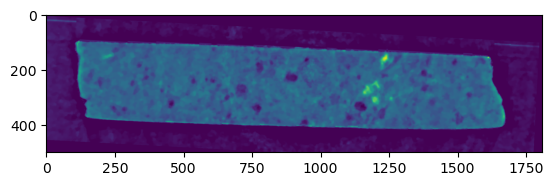

In [6]:
plt.imshow(absorption)
plt.show()
plt.imshow(XA_)
plt.show()
plt.imshow(NA_)
plt.show()

In [7]:
data_dir = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal'
theta_reg = False
threshold = 3.5
slice_index = 20
index_list, all_files = get_index_list(data_dir, theta_reg = theta_reg, slice_index=slice_index)
extra_filename = '/dtu-compute/msaca/sliceA_diffraction/abs_volume/XA_and_NA_x_5.h5'
dataset = ThresholdedH5Dataset(index_list, threshold=threshold, extra_filename=extra_filename,
                                slice_index = slice_index,
                                N_splits = 2,
                                split = [1,1,1])
N_2theta = 667
max_blur = 6
num_blur = 12
method = 'GPU_Lasso'
alpha = 0.005
num_background = 5
background_filter_sigma = None
box = None
j_global = 40
k_global = 100


w = np.ones(N_2theta)
spectra = load_xy_files('/dtu-compute/msaca/sliceA_diffraction/cif-files_and_theoretical_pd_spectra/PowderDiff_shortlist')
stds = np.linspace(0.1,max_blur,num_blur)
spectra = add_convolved_columns(spectra, stds)
num_materials = len(spectra)
key_to_name = simplified_keys()
keys = spectra.keys()
with h5py.File("/dtu-compute/msaca/sliceA_diffraction/abs_volume/overview_abs_volume.h5", "r") as f:
    # List all groups and datasets
    print("Keys:", list(f.keys()))
    
    # Access a dataset (replace 'dataset_name' with an actual name from the keys)
    dataset_abs = f["absorption"]
    DA_2 = dataset_abs[:,130:230]

absorption = DA_2[slice_index]
mask = absorption>0.002

A, keys = resample_all_blurs(spectra, start_col=2, target_x=np.linspace(0.01, 18.408, N_2theta))
if background_filter_sigma is None:
    A = add_fourier_background_basis(A, np.linspace(0,18.4,N_2theta), num_frequencies=num_background)

if box is None:
    box = [0, 100, 0, 362]  # default full region
ny = box[1] - box[0]
nx = box[3] - box[2]

att_xray = np.zeros(A.shape[1])
att_neutron = np.zeros(A.shape[1])

att_xray[:num_blur*num_materials] = np.repeat(coef_xray,num_blur)
att_neutron[:num_blur*num_materials] = np.repeat(coef_neutron,num_blur)
A_ = np.vstack([A,100*att_xray,100*att_neutron])
print(np.shape(A), np.shape(A_))

w = np.ones(N_2theta+2)
w[:100] = 0
w[-2] = 100000
w[-2] = 1000


Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0379.h5 with shape (667, 100, 362)
Total samples: 36200
Keys: ['absorption']
(667, 202) (669, 202)


In [8]:
N_splits = 1

full_slice_data = np.empty((N_splits, N_splits, N_splits, num_materials, ny, nx))
for i in range(N_splits):
    for j in range(N_splits):
        for l in range(N_splits):
            dataset = ThresholdedH5Dataset(index_list, threshold=threshold, extra_filename=extra_filename,
                                            slice_index = slice_index,
                                            N_splits = N_splits,
                                            split = [i,j,l])
            materials1 = fit_all_pixels(dataset, A_, alpha=0.01, box=box,background_filter_sigma = None, method = method, w=w)
            if background_filter_sigma is None:
                materials1_ = materials1[:-(2*num_background)]

            materials1_4d = materials1_.reshape(num_materials, num_blur, ny, nx)
            materials1_summed = materials1_4d.sum(axis=1)
            full_slice_data[i,j,l] = materials1_summed
            print('Fitted split', [i,j,l])
            

Fitted split [0, 0, 0]


In [9]:
full_slice_data_rearranged = np.empty((num_materials, N_splits*ny, N_splits*nx, N_splits))
for i in range(N_splits):
    for j in range(N_splits):
        for l in range(N_splits):
            full_slice_data_rearranged[:,i::N_splits, j::N_splits, l::N_splits] = full_slice_data[ i,j,l,:,:,:, np.newaxis]

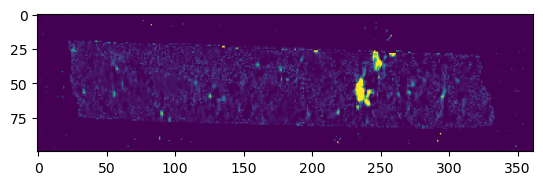

0.005337740214585805


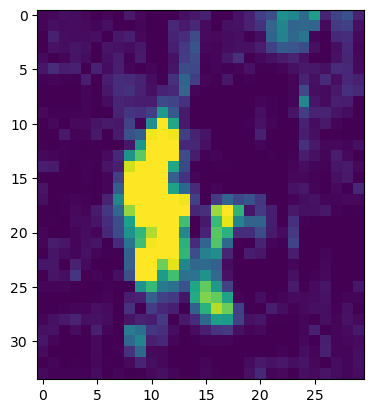

0.005337740214585805


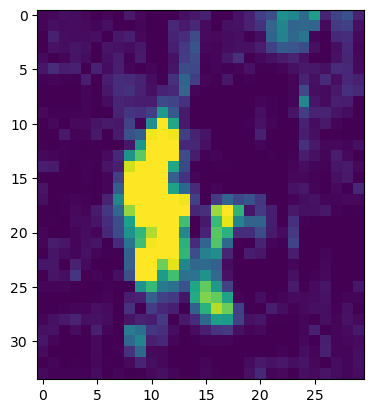

In [10]:
NN = 0
plt.imshow(full_slice_data_rearranged[NN,:,:,0])
plt.clim([0,0.05])
plt.show()
plt.imshow(full_slice_data[0,0,0,NN,:,:])
plt.clim([0,0.05])
print(np.mean(full_slice_data))


NN = 0
plt.imshow(full_slice_data_rearranged[NN,:,:,0][38*N_splits:72*N_splits, 225*N_splits:255*N_splits])
plt.clim([0,0.1])
plt.show()
plt.imshow(full_slice_data[0,0,0,NN,:,:][38:72, 225:255])
plt.clim([0,0.1])
print(np.mean(full_slice_data))

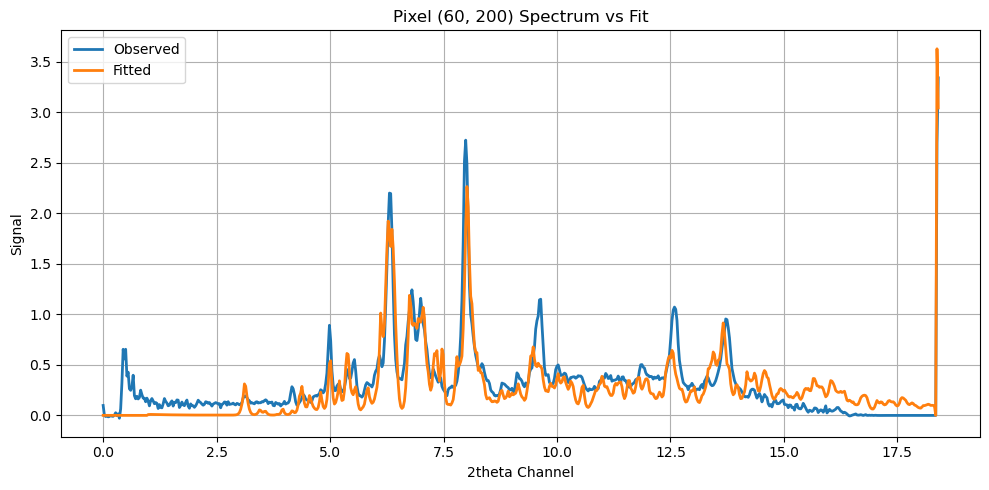

Name                      | Scaled Value
-----------------------------------------------------------------
Enstatite                 | 0.1559
Albite                    | 0.1384
Diopside                  | 0.1158
Ferrosilite               | 0.0812
Magnetite                 | 0.0725
Orthoclase                | 0.0602
Forsterite                | 0.0405
Chlorapatite              | 0.0384
Ilmenite                  | 0.0382
Spinel                    | 0.0375
Hematite                  | 0.0373
Rutile                    | 0.0370
Pyrite                    | 0.0369
Zircon                    | 0.0369
Baddeleyite               | 0.0367
Wüstite                   | 0.0366


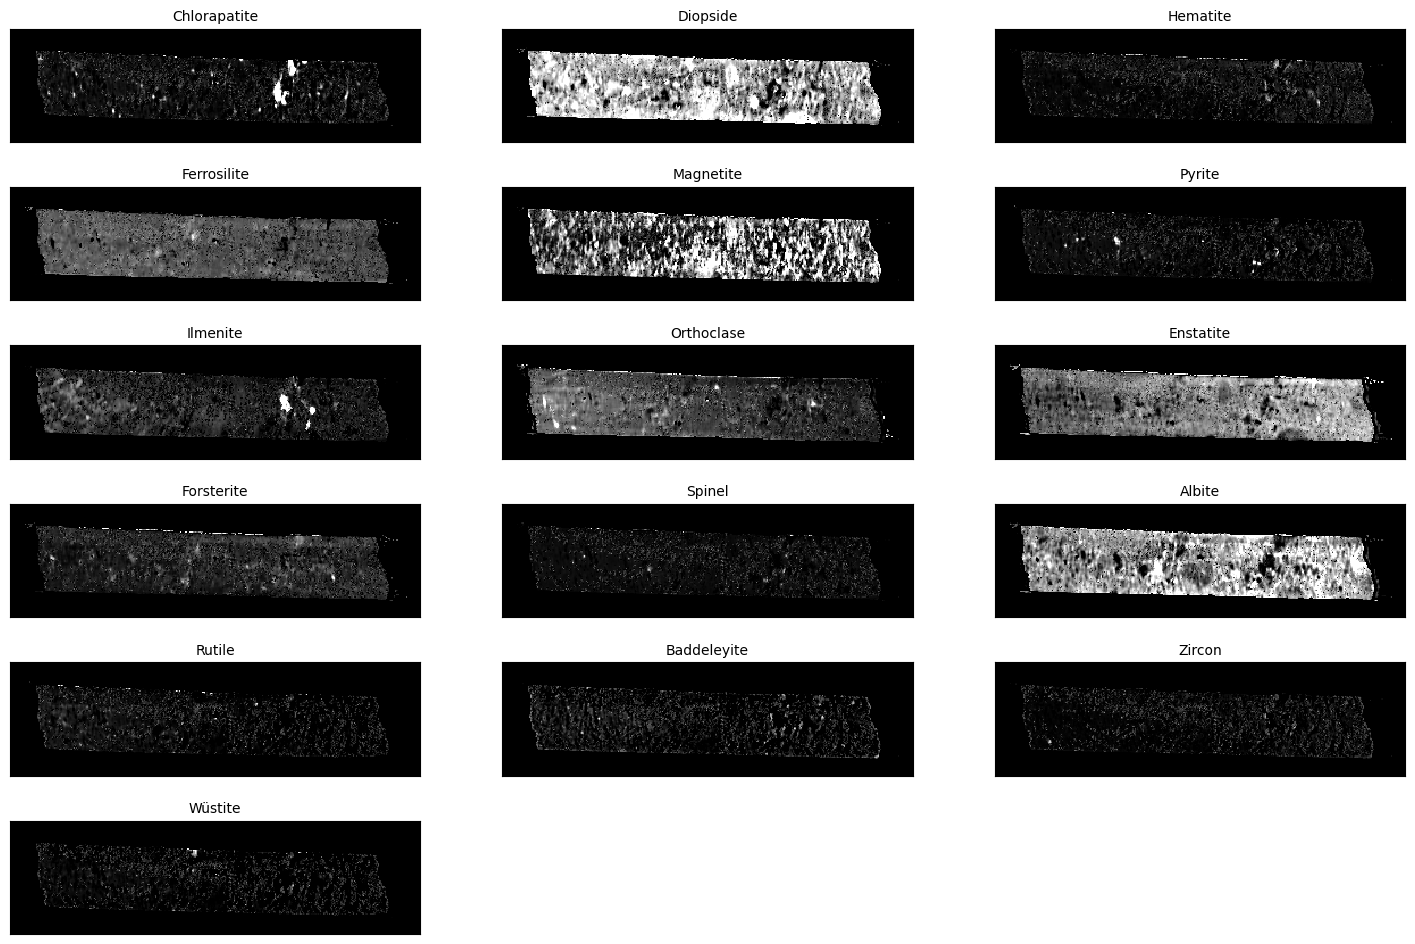

In [11]:
j_global = 60
k_global = 200

if display:
    plot_pixel_fit(j_global=j_global, k_global=k_global, dataset=dataset, materials=materials1,
            A=A_, box=box,filename=all_files[0], background_filter_sigma=background_filter_sigma)
materials1_mean = materials1[:-2*num_background].reshape(num_materials, num_blur, *materials1.shape[1:]).mean(axis=1)

if display:
    plot_material_maps_only(mask[np.newaxis]*materials1_mean, keys, key_to_name, num_cols=3)

if background_filter_sigma is None:
    materials1_ = materials1[:-(2*num_background)]

materials1_4d = materials1_.reshape(num_materials, num_blur, ny, nx)
materials1_summed = materials1_4d.sum(axis=1)

if display:
    print_nonzero_material_coeffs(materials1_summed[:,j_global-box[0],k_global-box[2]], keys, key_to_name, num_background=6, threshold=1e-8)



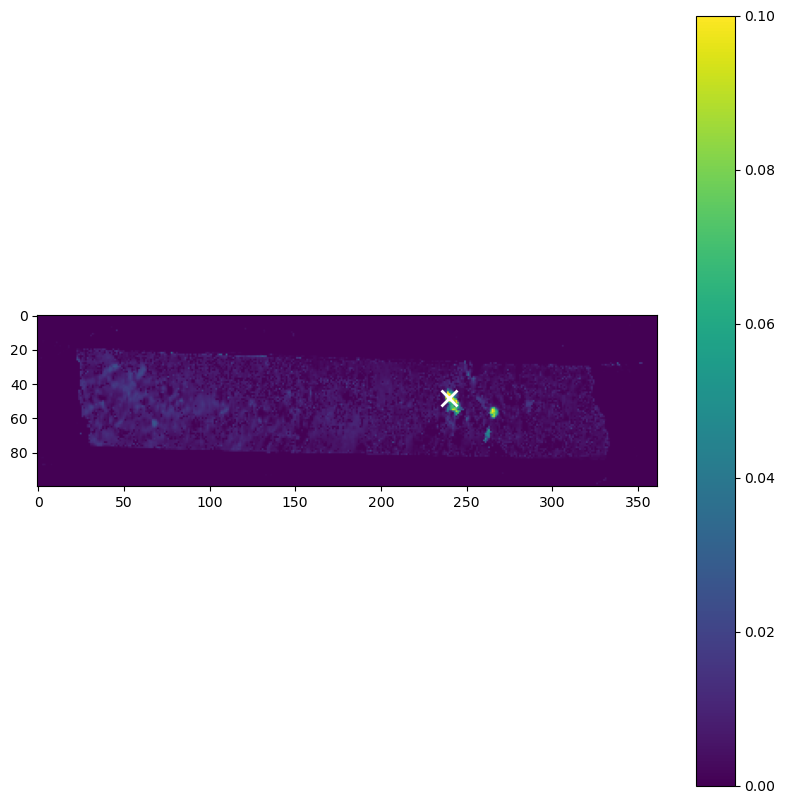

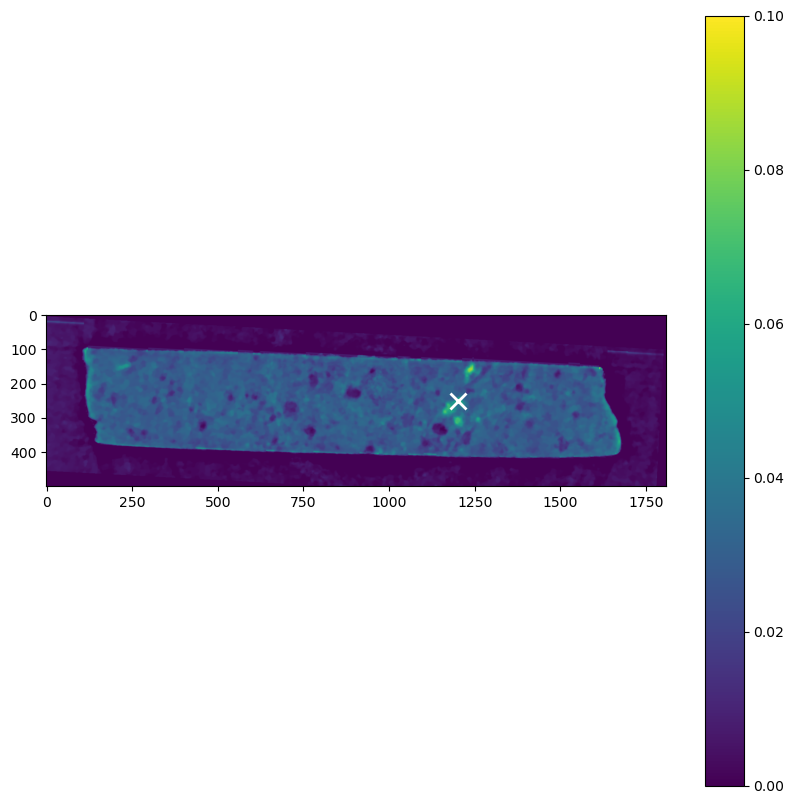

0.0579235


In [12]:
plt.figure(figsize=(10,10))
plt.imshow(materials1_summed[6])
j_global, k_global = 48, 240
plt.plot(k_global, j_global, 'x', color='white', markersize=12, markeredgewidth=2)

plt.colorbar()
plt.clim([0,0.1])
plt.show()

plt.figure(figsize=(10,10))
plt.imshow(NA_)
j_global, k_global = 5*50, 5*240
plt.plot(k_global, j_global, 'x', color='white', markersize=12, markeredgewidth=2)

plt.colorbar()
plt.clim([0,0.1])
plt.show()

print(np.mean(NA_[j_global-5:j_global+5, k_global-5:k_global+5]))

In [13]:
def downsample_5x5_blocks(arr):
    assert arr.shape[0] % 5 == 0 and arr.shape[1] % 5 == 0, "Shape must be divisible by 5"
    N0, N1 = arr.shape[0] // 5, arr.shape[1] // 5
    return arr.reshape(N0, 5, N1, 5).mean(axis=(1, 3))

XA_d = downsample_5x5_blocks(XA_)
NA_d = downsample_5x5_blocks(NA_)

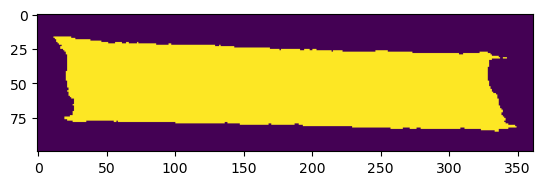

In [14]:
plt.imshow(mask)

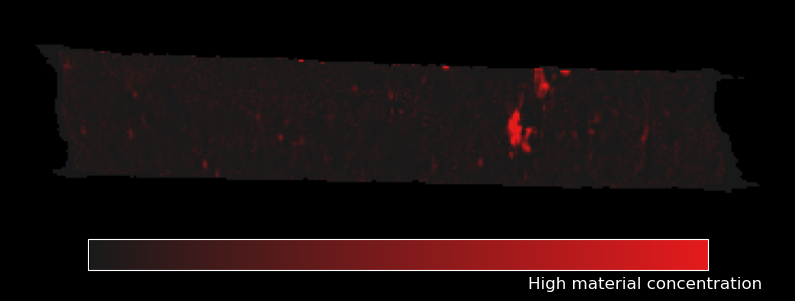

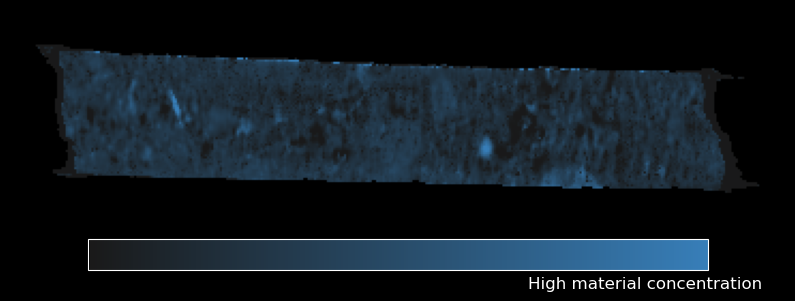

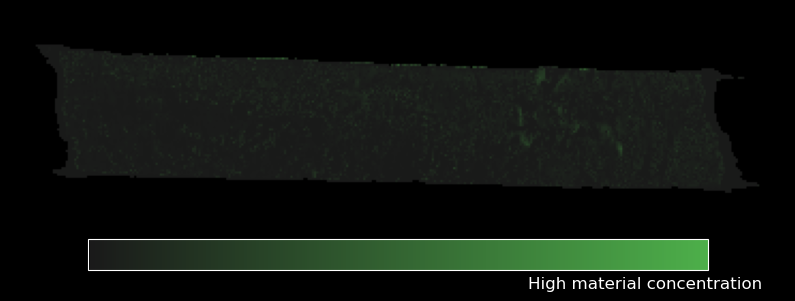

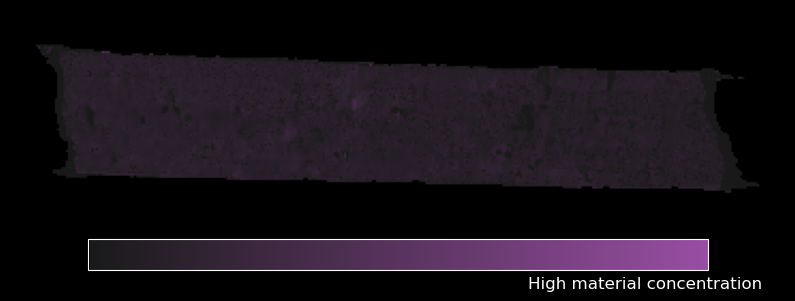

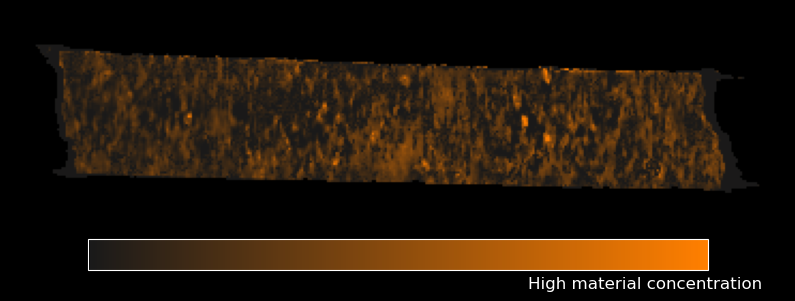

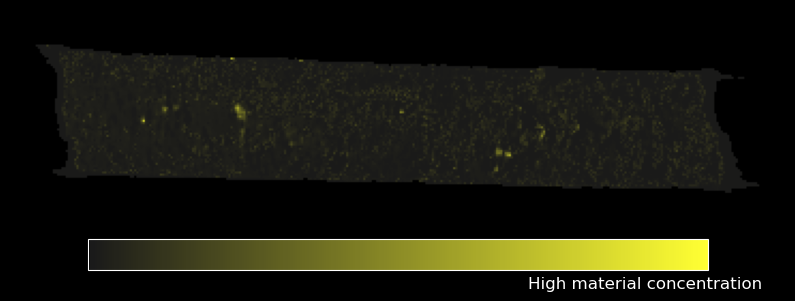

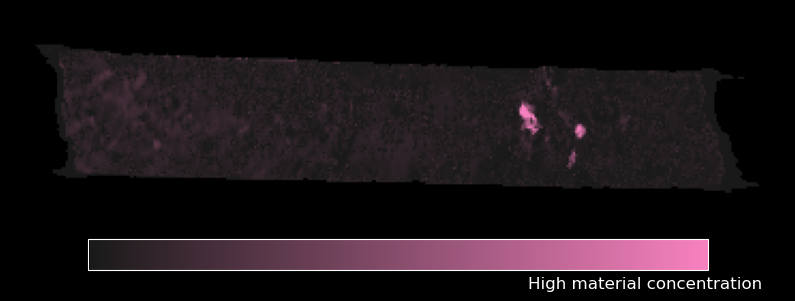

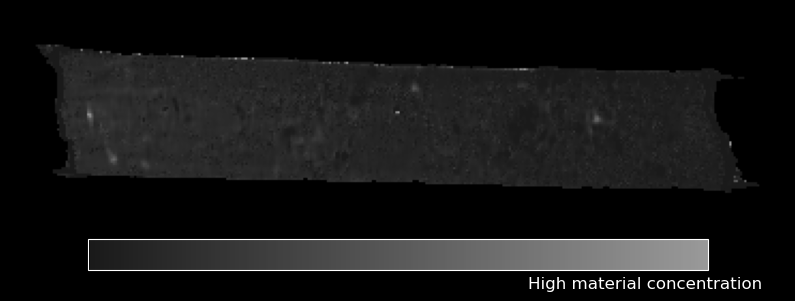

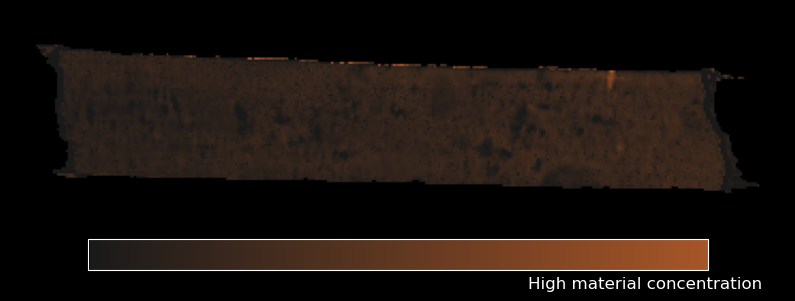

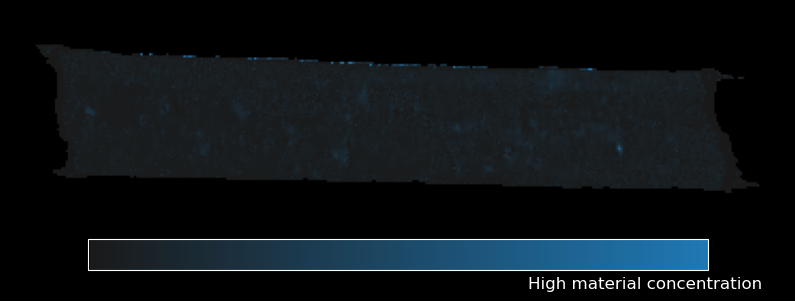

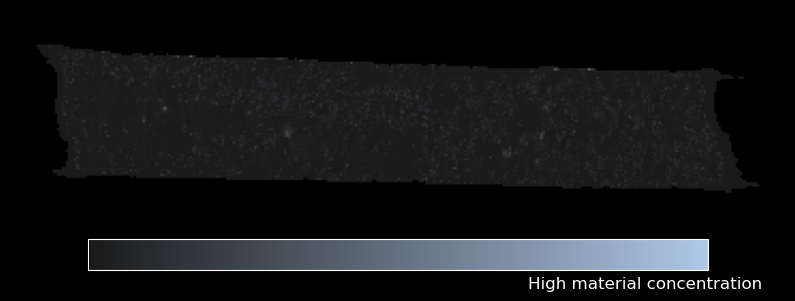

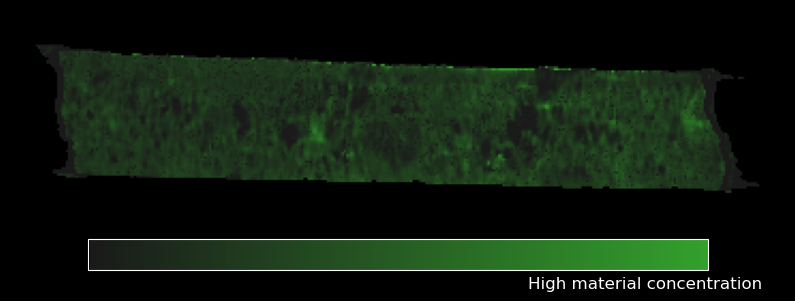

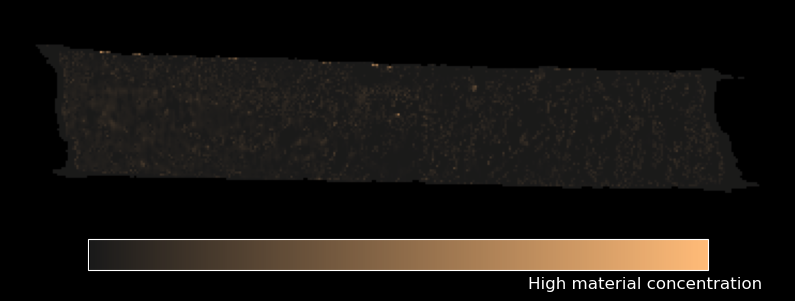

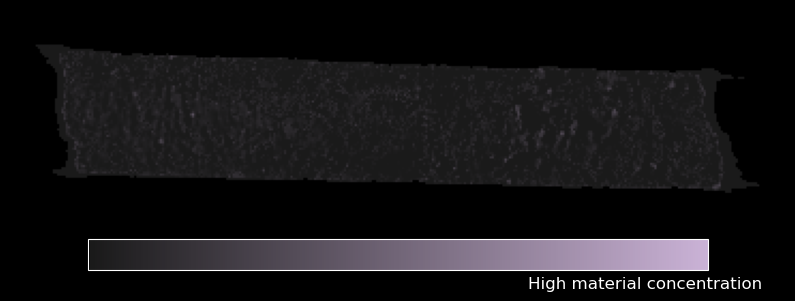

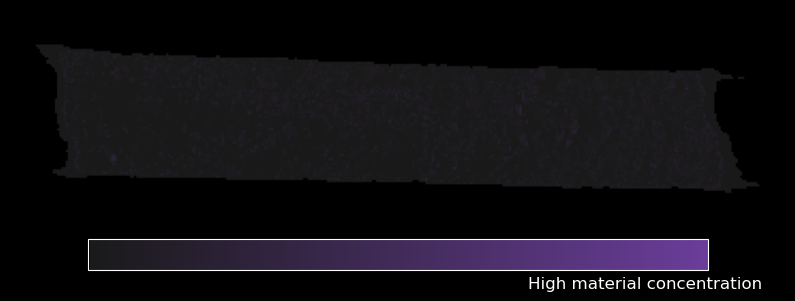

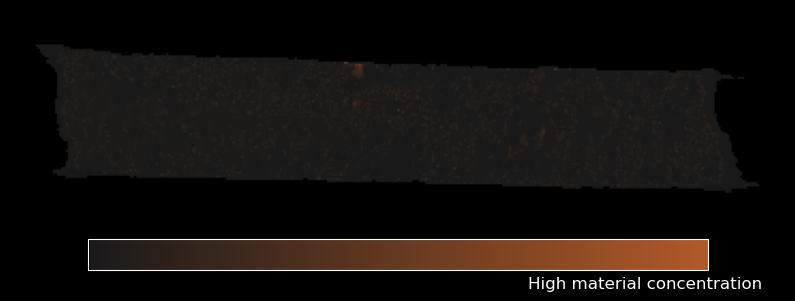

In [15]:
from matplotlib.colors import ListedColormap, BoundaryNorm
distinct_colors = [
    (0.894, 0.102, 0.110),  # red
    (0.216, 0.494, 0.722),  # blue
    (0.302, 0.686, 0.290),  # green
    (0.596, 0.306, 0.639),  # purple
    (1.000, 0.498, 0.000),  # orange
    (1.000, 1.000, 0.200),  # yellow
    (0.969, 0.506, 0.749),  # pink
    (0.600, 0.600, 0.600),  # grey
    (0.651, 0.337, 0.157),  # brown
    (0.121, 0.470, 0.705),  # steel blue
    (0.682, 0.780, 0.909),  # light blue
    (0.199, 0.627, 0.173),  # dark green
    (1.000, 0.733, 0.470),  # peach
    (0.792, 0.698, 0.839),  # lavender
    (0.415, 0.239, 0.603),  # indigo
    (0.694, 0.349, 0.157),  # rust
]


for i in range(16):
    material_name = keys_simple[i]
    # Generate example data
    raw_data = materials1_summed[i]
    mask = absorption < 0.002

    # Copy to avoid modifying original
    data = raw_data.copy()
    data[mask] = -1
    # === SET YOUR PARAMETERS ===

    # Target color as RGB in [0, 1]
    target_rgb = distinct_colors[i]

    # Colormap intensity range (clim)
    vmin = 0
    vmax = 0.1

    # ============================

    # Mask out the special value (-1)
    masked_data = np.ma.masked_where(data == -1, data)

    # Create gradient from dark gray to target color
    N = 256
    dark_gray = 0.1
    gradient = np.linspace(0, 1, N).reshape(-1, 1)
    color_gradient = gradient * np.array(target_rgb) + (1 - gradient) * dark_gray

    # Final colormap: black for -1, followed by gradient
    colors = np.vstack([
        [0.0, 0.0, 0.0],  # for -1
        color_gradient
    ])
    cmap = ListedColormap(colors)

    # Create norm: value -1 maps to index 0, vmin..vmax maps to 1..N
    boundaries = [-1.5, -0.5] + list(np.linspace(vmin, vmax, N))
    norm = BoundaryNorm(boundaries=boundaries, ncolors=cmap.N)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')

    # Show image
    im = ax.imshow(data, cmap=cmap, norm=norm)

    # No axes
    ax.axis('off')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', shrink=0.8, pad=0.02)
    cbar.set_ticks([])

    # Labels
    cbar.ax.text(0.9, -0.2, 'High material concentration', ha='center', va='top', color='white', fontsize=12, transform=cbar.ax.transAxes)

    # Style colorbar
    cbar.outline.set_edgecolor('white')
    cbar.ax.tick_params(color='white')
    cbar.ax.set_facecolor('black')

    # Save
    plt.savefig('/dtu-compute/msaca/visualizations/QIM_presentation/material_decomp_' + material_name + '.png', bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

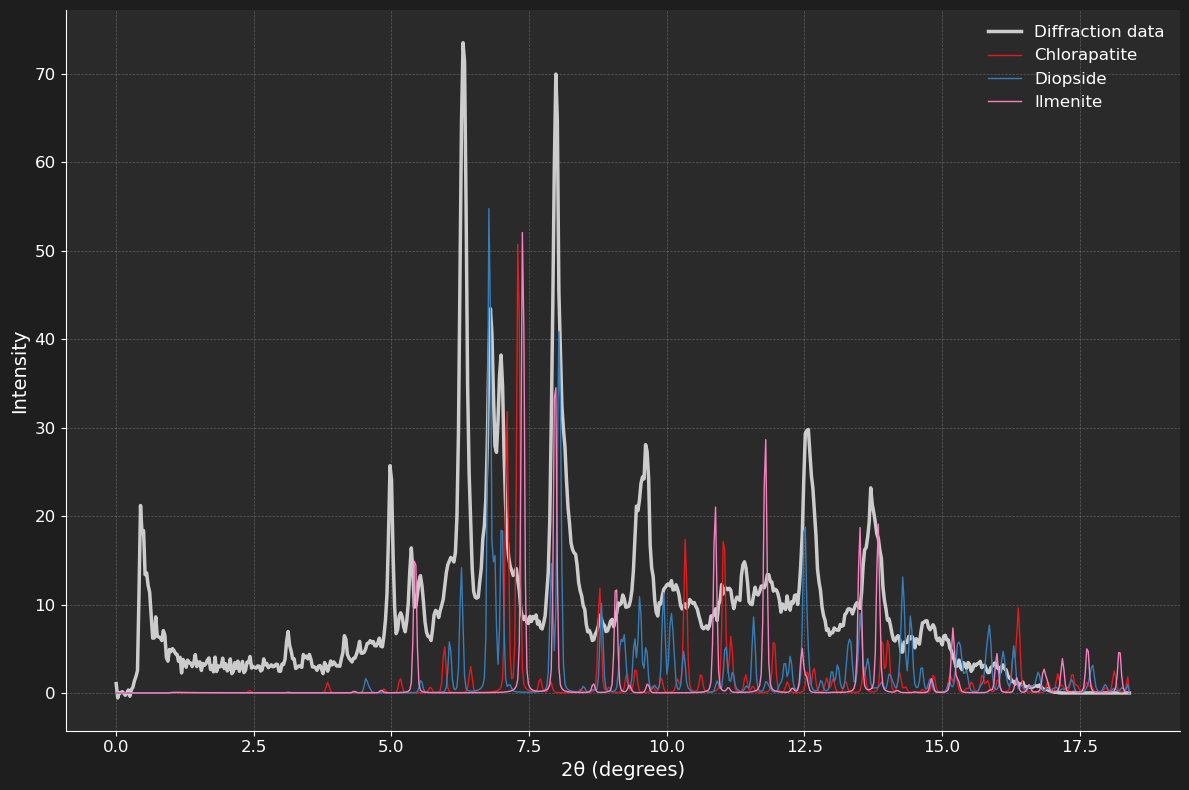

In [24]:
j_global = 40
k_global = 100
twotheta = np.linspace(0,18.4,667)
idx = dataset.index_list.index((all_files[0], j_global, k_global))

datasets = [np.sin(0.1 * twotheta + i) + i*0.5 for i in range(5)]  # 5 curves
curve_data = []

selected_material_indices = (0,1,6)



for i in selected_material_indices:
    curve_data.append(A[:,i*num_blur + 4])

# Distinct color palette (bright, suitable for dark background)

# Create plot
fig, ax = plt.subplots(figsize=(12, 8))

# Dark grey background
fig.patch.set_facecolor('#1e1e1e')   # around the figure
ax.set_facecolor('#2a2a2a')          # inside the axes

ax.plot(twotheta, 30*dataset[idx][:-2], linewidth=2.5, color=(0.8,0.8,0.8), label=f'Diffraction data')
# Plot each curve
for i, idx in zip(range(len(curve_data)), selected_material_indices):
    material_name = keys_simple[idx]
    ax.plot(twotheta, curve_data[i], linewidth=1.0, color=distinct_colors[idx], label=material_name)

# Grid and axes styling
ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

# Labels and ticks
ax.set_xlabel('2θ (degrees)', fontsize=14, color='white')
ax.set_ylabel('Intensity', fontsize=14, color='white')
ax.tick_params(colors='white', labelsize=12)

# Legend
ax.legend(frameon=False, fontsize=12, labelcolor='white')

# Tight layout
plt.tight_layout()
plt.savefig('/dtu-compute/msaca/visualizations/QIM_presentation/twotheta_spectrum_3.png', dpi=300)
plt.show()